# Implementation of a Deep Asset Liability Management Environment

In [12]:
import os
import sys
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

from environment.config import markov_config
from environment.bond import Bond
from environment.env import DeepALMEnv
from models.utils import print_bond_universe, plot_learning_curve, plot_final_wealth
from models.source.ppo import evaluate_ppo_agent, evaluate_ppo_alm
from models.DirichletPolicy import DirichletActorCriticPolicy
from typing import Callable

In [13]:
TRAINING = True
DIRICHLET = False

In [14]:
if DIRICHLET:
    # Create logging directory
    log_dir = "tmp_log/PPO/Dirichlet"
    os.makedirs(log_dir, exist_ok=True)
else:
    log_dir = "tmp_log/PPO/Gaussian"
    os.makedirs(log_dir, exist_ok=True)

## Gym Wrapper for SB3 compatibility

In [15]:
# Create and display bond universe
bonds = [Bond(**cfg) for cfg in markov_config["bond_configs"]]
K = len(bonds)
print_bond_universe(bonds)

# Initialize Training Environment
env = DummyVecEnv([lambda: Monitor(
    DeepALMEnv(markov_config=markov_config, seed=None, use_dirichlet=DIRICHLET), 
    filename=os.path.join(log_dir, "monitor.csv"), 
    info_keywords=('nav',)
)])

-----------------------------------------------
| Bond Type            | Maturity (Months)    |
-----------------------------------------------
| 1M_Bill              | 1                    |
| 3M_ZeroCoupon        | 3                    |
| 6M_ZeroCoupon        | 6                    |
| 12M_6Months          | 12                   |
| 24M_6Months          | 24                   |
-----------------------------------------------


In [16]:
# Linear Schedule Helper for Learning Rate
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    """
    Linear learning rate schedule.
    :param initial_value: Initial learning rate.
    :return: schedule that computes current rate depending on remaining progress
    """
    def func(progress_remaining: float) -> float:
        # progress_remaining starts at 1.0 and goes to 0.0
        return progress_remaining * initial_value
    return func

model = PPO(
    policy=DirichletActorCriticPolicy if DIRICHLET else "MultiInputPolicy",
    env=env,

    learning_rate=9.307225283874309e-05,
    n_steps=512,
    batch_size=64,
    n_epochs=10,

    gamma=1.0,         # No discounting: because we care about terminal utility
    gae_lambda=0.95,

    use_sde=False,
    ent_coef=0.001847959453631033,

    policy_kwargs=dict(
        net_arch=dict(pi=[256, 256], vf=[256, 256]),
        log_std_init=-2,
    ),

    verbose=1,
    device="auto"
)



Using cpu device


In [ ]:
if TRAINING:
    print("Starting PPO training...")
    model.learn(total_timesteps=1_000_000, log_interval=10)
    print("Training completed.")
    model.save("saved_models/ppo_alm.zip")
else:
    print("Loading pre-trained model...")
    model = PPO.load("saved_models/ppo_alm.zip")


Starting PPO training...


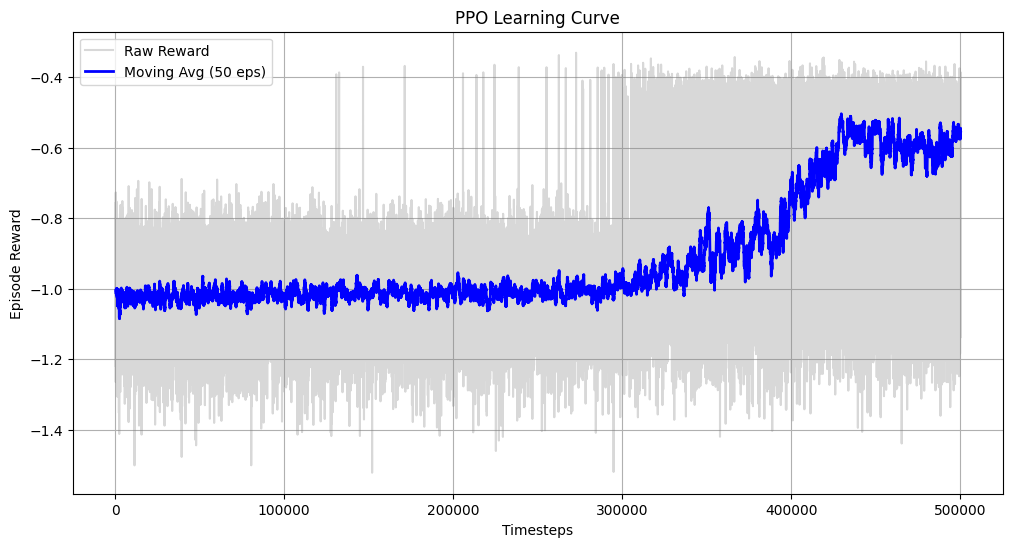

In [ ]:
if TRAINING:
    plot_learning_curve(log_dir, "PPO Learning Curve")

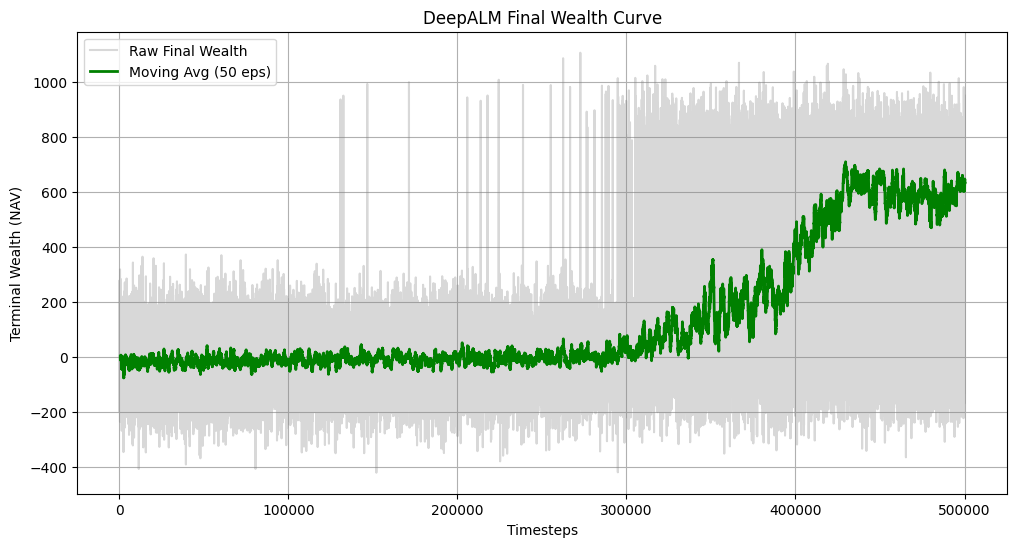

In [ ]:
if TRAINING:
    plot_final_wealth(log_dir)

In [ ]:
# Single-episode evaluation
print("\nRunning Single Episode Deep Dive")
evaluate_ppo_agent(model, markov_config, K, seed=0, verbose=True);


Running Single Episode Deep Dive
Month 1:
1M Bond Lots: None
3M Bond Lots: None
6M Bond Lots: None
12M Bond Lots: None
24M Bond Lots: None
  Current Market Yields
    1M: 1.96%
    3M: 2.54%
    6M: 2.90%
    12M: 3.13%
    24M: 3.29%
  Cash Before Action: 2000.00
  Inflows: 0.00  |  Liability Due: 59.29  |  Next Liability: 59.29
  Cash After Action: 316.32
  LCR: 16.8862  |  Utility: -0.47
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  | Bond Type       |        1M        2M        3M        4M        5M        6M        7M        8M        9M       10M       11M       12M       13M       14M       15M       16M       17M       18M       19M       20M       21M       22M       23M       24M |      Total |
  -----------------------------------------------

In [ ]:
# Out-of-sample statistical evaluation
model = PPO.load("saved_models/ppo_alm.zip")
print("\nRunning Out-Of-Sample Evaluation")
eval_metrics, eval_raw_results = evaluate_ppo_alm(
    model=model,                       
    markov_config=markov_config,       
    eval_episodes=2000,                
    seed_offset=1000001,               
    verbose_first_episode=True         
)


Running Out-Of-Sample Evaluation

--- Starting PPO Evaluation ---
Ep 0 | Month  1 | NAV:   687.57 | LCR: 21.90 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   700.72 | LCR:  5.56 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   691.85 | LCR: 10.50 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   692.88 | LCR: 12.13 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   705.21 | LCR:  3.84 | Step Reward: 0.00
Ep 0 | Month  6 | NAV:   698.32 | LCR:  5.99 | Step Reward: 0.00
Ep 0 | Month  7 | NAV:   716.97 | LCR:  4.57 | Step Reward: 0.00
Ep 0 | Month  8 | NAV:   725.74 | LCR:  3.22 | Step Reward: 0.00
Ep 0 | Month  9 | NAV:   715.05 | LCR:  3.64 | Step Reward: 0.00
Ep 0 | Month 10 | NAV:   730.32 | LCR:  4.36 | Step Reward: 0.00
Ep 0 | Month 11 | NAV:   716.16 | LCR:  4.03 | Step Reward: 0.00
Ep 0 | Month 12 | NAV:   717.85 | LCR:  4.19 | Step Reward: 0.00
Ep 0 | Month 13 | NAV:   697.53 | LCR:  7.40 | Step Reward: 0.00
Ep 0 | Month 14 | NAV:   698.74 | LCR:  6.00 | Step Reward: 0.00
Ep 0 | Month 15 | NAV: 

In [ ]:
# Out-of-sample statistical evaluation
model = PPO.load("saved_models/ppo_alm.zip")
print("\nRunning Out-Of-Sample Evaluation")
eval_metrics, eval_raw_results = evaluate_ppo_alm(
    model=model,                       
    markov_config=markov_config,       
    eval_episodes=100_000,                
    seed_offset=1000001,               
    verbose_first_episode=True         
)


Running Out-Of-Sample Evaluation

--- Starting PPO Evaluation ---
Ep 0 | Month  1 | NAV:   687.57 | LCR: 21.90 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   700.72 | LCR:  5.56 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   691.85 | LCR: 10.50 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   692.88 | LCR: 12.13 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   705.21 | LCR:  3.84 | Step Reward: 0.00
Ep 0 | Month  6 | NAV:   698.32 | LCR:  5.99 | Step Reward: 0.00
Ep 0 | Month  7 | NAV:   716.97 | LCR:  4.57 | Step Reward: 0.00
Ep 0 | Month  8 | NAV:   725.74 | LCR:  3.22 | Step Reward: 0.00
Ep 0 | Month  9 | NAV:   715.05 | LCR:  3.64 | Step Reward: 0.00
Ep 0 | Month 10 | NAV:   730.32 | LCR:  4.36 | Step Reward: 0.00
Ep 0 | Month 11 | NAV:   716.16 | LCR:  4.03 | Step Reward: 0.00
Ep 0 | Month 12 | NAV:   717.85 | LCR:  4.19 | Step Reward: 0.00
Ep 0 | Month 13 | NAV:   697.53 | LCR:  7.40 | Step Reward: 0.00
Ep 0 | Month 14 | NAV:   698.74 | LCR:  6.00 | Step Reward: 0.00
Ep 0 | Month 15 | NAV: 